Using device: mps


/var/folders/_3/jggbxqpj77x_m8nr3ll39p5r0000gn/T/ipykernel_34359/3885354899.py:135: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/opt/anaconda3/envs/cad_pointcloud/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


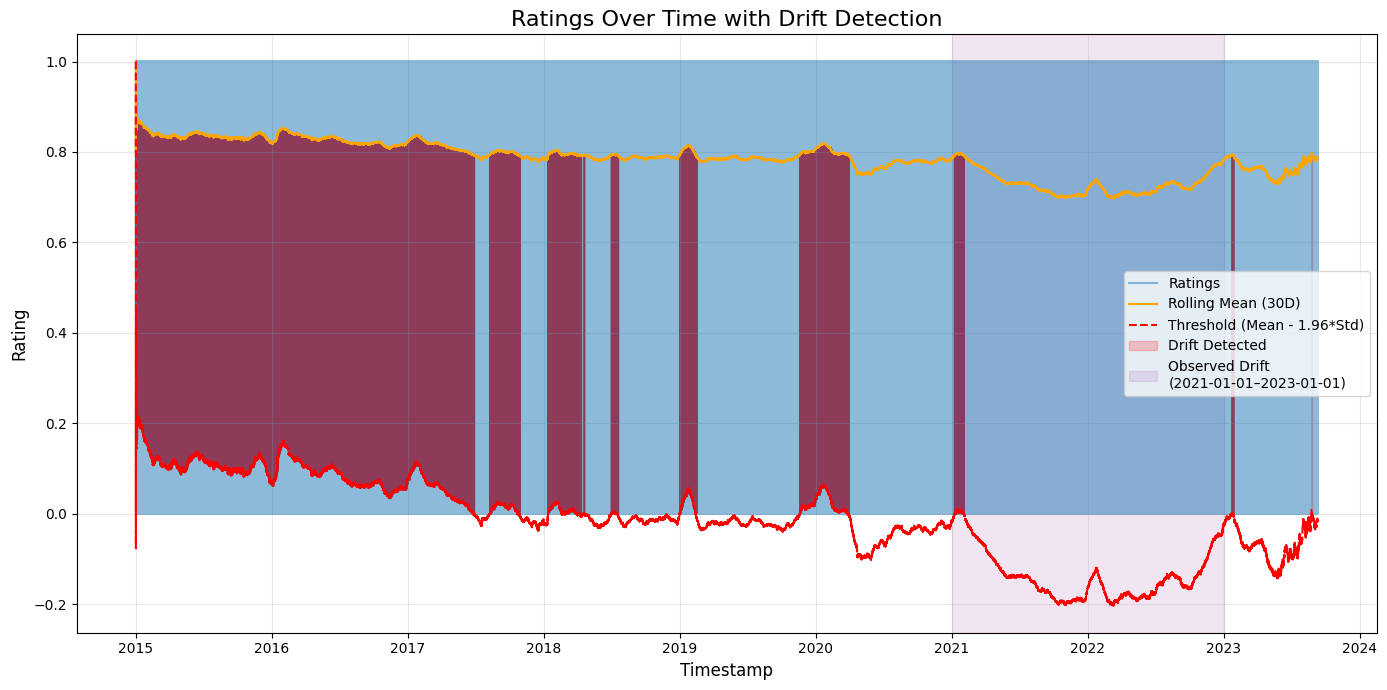

Data columns: Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'helpful_vote', 'verified_purchase', 'drift_flag'],
      dtype='object')
Total length of data: 2166931
drift_flag distribution:
 drift_flag
False    2000489
True      166442
Name: count, dtype: int64
asin unique: 798541
user_id unique: 1795694


/var/folders/_3/jggbxqpj77x_m8nr3ll39p5r0000gn/T/ipykernel_34359/3885354899.py:209: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data["asin_hashed"] = hash_column(train_data["asin"], HASH_BUCKET_SIZE)
/var/folders/_3/jggbxqpj77x_m8nr3ll39p5r0000gn/T/ipykernel_34359/3885354899.py:210: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_data["asin_hashed"] = hash_column(valid_data["asin"], HASH_BUCKET_SIZE)
/var/folders/_3/jggbxqpj77x_m8nr3ll39p5r0000gn/T/ipykernel_34359/3885354899.py:212: SettingWithC


Training on data up to 2020, validating on 2021+...
mps
Train on 1698907 samples, validate on 468024 samples, 1660 steps per epoch
Epoch 1/6
331s - loss:  0.4851
Epoch 2/6
327s - loss:  0.2807
Epoch 3/6
335s - loss:  0.1801
Epoch 4/6
372s - loss:  0.0643
Epoch 5/6
375s - loss:  0.0183
Epoch 6/6
375s - loss:  0.0065


In [1]:
# %%
!pip install numpy pandas torch scikit-learn deepctr-torch

# %%
#################################
# Imports & Basic Setup
#################################
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import os
import hashlib

from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

from deepctr_torch.inputs import SparseFeat, get_feature_names
from deepctr_torch.models import DeepFM

# For reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Decide on device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)


#################################
# 1. Hashing for High-Cardinality Features
#################################
def hash_column(series, num_buckets=1_000_000):
    """
    Convert each value in the series to a hash mod `num_buckets`.
    This avoids building a massive mapping for each unique value.
    """
    # Convert once to string, then apply hashing
    series_str = series.astype(str)
    
    # Use MD5 hashing and mod by num_buckets
    hashed_vals = series_str.apply(
        lambda x: int(hashlib.md5(x.encode("utf-8")).hexdigest(), 16) % num_buckets
    )
    return hashed_vals


#################################
# 2. Data Loading & Preprocessing
#################################
def load_preprocess_data(filepath, cutoff_date="2015-01-01"):
    """
    1. Load data from JSON lines
    2. Filter out rating=3
    3. Filter by timestamp > cutoff_date
    4. Convert rating to binary (1 if > 3, else 0)
    5. Index by 'timestamp' and sort
    6. Return the DataFrame
    """
    data = pd.read_json(filepath, lines=True)

    # Filter out neutral ratings
    data = data[data["rating"] != 3]
    # Filter by date
    data = data[data["timestamp"] > cutoff_date]
    # Binarize rating
    data["rating"] = data["rating"].apply(lambda x: 1 if x > 3 else 0)

    # Index by timestamp
    data = data.set_index("timestamp")
    data.sort_index(inplace=True)
    return data

def mark_drift(data, window="30D", threshold_factor=1.96):
    """
    Use a rolling window to mark drift periods where:
       rating < rolling_mean - threshold_factor * rolling_std
    """
    rolling_mean = data["rating"].rolling(window).mean()
    rolling_std = data["rating"].rolling(window).std()
    significance_threshold = rolling_mean - threshold_factor * rolling_std

    data["drift_flag"] = (data["rating"] < significance_threshold).fillna(False)
    return data, rolling_mean, significance_threshold

def visualize_drift(data, rolling_mean, significance_threshold, 
                    start_drift="2021-01-01", end_drift="2023-01-01"):
    """
    Plot rating over time, rolling mean, threshold, and highlight drift_flag.
    """
    plt.figure(figsize=(14, 7))
    # Plot raw ratings
    plt.plot(data.index, data["rating"], label="Ratings", alpha=0.5)
    # Plot rolling mean
    plt.plot(data.index, rolling_mean, label="Rolling Mean (30D)", color="orange")
    # Plot threshold
    plt.plot(
        data.index, 
        significance_threshold, 
        label="Threshold (Mean - 1.96*Std)", 
        color="red", 
        linestyle="--"
    )

    # Highlight drift periods
    plt.fill_between(
        data.index,
        rolling_mean,
        significance_threshold,
        where=data["drift_flag"],
        color="red",
        alpha=0.2,
        label="Drift Detected",
    )

    # Optional highlight observed drift
    plt.axvspan(
        pd.Timestamp(start_drift), 
        pd.Timestamp(end_drift), 
        color="purple", 
        alpha=0.1, 
        label=f"Observed Drift\n({start_drift}–{end_drift})"
    )

    plt.title("Ratings Over Time with Drift Detection", fontsize=16)
    plt.xlabel("Timestamp", fontsize=12)
    plt.ylabel("Rating", fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


#################################
# 3. Mahalanobis Drift Detector
#################################
def compute_mahalanobis_distance(mean, cov_inv, embedding):
    """
    Compute Mahalanobis distance of 'embedding' from current mean/cov_inv.
    """
    diff = embedding - mean
    return np.sqrt(diff.T @ cov_inv @ diff)

class DriftDetector:
    """
    Incremental Mahalanobis-based drift detection.
    Updates running mean & covariance with a learning rate 'alpha'.
    """

    def __init__(self, embedding_dim, alpha=0.01):
        self.alpha = alpha
        self.mean = np.zeros(embedding_dim)
        self.cov = np.eye(embedding_dim)
        self.count = 0

    def update(self, embedding):
        if self.count == 0:
            self.mean = embedding
            self.cov = np.eye(len(embedding))
        else:
            self.mean = (1 - self.alpha) * self.mean + self.alpha * embedding
            diff = embedding - self.mean
            self.cov = (1 - self.alpha) * self.cov + self.alpha * np.outer(diff, diff)
        self.count += 1

    def detect_drift(self, embedding):
        cov_inv = np.linalg.pinv(self.cov)
        return compute_mahalanobis_distance(self.mean, cov_inv, embedding)


#################################
# 4. Main Execution
#################################
# ======== 4.1 Load Data & Mark Rolling-Mean Drift  ========
filepath = "experiment_1/Amazon_Fashion.jsonl"
data = load_preprocess_data(filepath, cutoff_date="2015-01-01")
data, rolling_mean, significance_threshold = mark_drift(data, "30D", 1.96)

# Optional: Visualize
visualize_drift(
    data, 
    rolling_mean, 
    significance_threshold,
    start_drift="2021-01-01", 
    end_drift="2023-01-01"
)

# Print Basic Stats
print("Data columns:", data.columns)
print("Total length of data:", len(data))
print("drift_flag distribution:\n", data["drift_flag"].value_counts())
print("asin unique:", data["asin"].nunique())
print("user_id unique:", data["user_id"].nunique())

# ======== 4.2 Time-based Split: Train <= 2020, Valid >= 2021 ========
train_data = data.loc[:'2020-12-31']
valid_data = data.loc['2021-01-01':]

# ======== 4.3 Hashing High-Cardinality Features  ========
# Instead of label encoding, we apply a hashing function.
# We create new columns (e.g., 'asin_hashed') so we don't overwrite original data.
HASH_BUCKET_SIZE = 1_000_000  # Adjust as needed

train_data["asin_hashed"] = hash_column(train_data["asin"], HASH_BUCKET_SIZE)
valid_data["asin_hashed"] = hash_column(valid_data["asin"], HASH_BUCKET_SIZE)

train_data["parent_asin_hashed"] = hash_column(train_data["parent_asin"], HASH_BUCKET_SIZE)
valid_data["parent_asin_hashed"] = hash_column(valid_data["parent_asin"], HASH_BUCKET_SIZE)

train_data["user_id_hashed"] = hash_column(train_data["user_id"], HASH_BUCKET_SIZE)
valid_data["user_id_hashed"] = hash_column(valid_data["user_id"], HASH_BUCKET_SIZE)

# We'll feed these hashed columns into DeepFM
sparse_features = ["asin_hashed", "parent_asin_hashed", "user_id_hashed"]
target = "rating"

# ======== 4.4 Build DeepFM Model  ========
embedding_dim = 8

# We set vocabulary_size = HASH_BUCKET_SIZE, because each hashed column
# has a range of [0, HASH_BUCKET_SIZE-1].
fixlen_feature_columns = [
    SparseFeat(feat, vocabulary_size=HASH_BUCKET_SIZE, embedding_dim=embedding_dim)
    for feat in sparse_features
]
linear_feature_columns = fixlen_feature_columns
dnn_feature_columns = fixlen_feature_columns
feature_names = get_feature_names(linear_feature_columns + dnn_feature_columns)

# Prepare model inputs
train_input = {name: train_data[name] for name in sparse_features}
valid_input = {name: valid_data[name] for name in sparse_features}

model = DeepFM(linear_feature_columns, dnn_feature_columns, task='binary', device=device)
model.compile(optimizer="adam", loss='binary_crossentropy', metrics=["AUC"])

# ======== 4.5 Train DeepFM  ========
print("\nTraining on data up to 2020, validating on 2021+...")
history = model.fit(
    train_input,
    train_data[target].values,
    batch_size=1024,
    epochs=6,  # Adjust as needed
    verbose=2,
    validation_data=(valid_input, valid_data[target].values),
)

In [5]:
# Save the model's state dictionary
torch.save(model.state_dict(), "deepfm_model.pth")

In [ ]:
model = DeepFM(linear_feature_columns, dnn_feature_columns, task='binary', device=device)
model.load_state_dict(torch.load("deepfm_model.pth"))


Performing Mahalanobis-based drift detection on validation set...


/opt/anaconda3/envs/cad_pointcloud/lib/python3.9/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Batch 46: Drift detected! Distance=0.0755, Threshold=0.0575
Batch 64: Drift detected! Distance=0.0909, Threshold=0.0774
Batch 263: Drift detected! Distance=0.1657, Threshold=0.1628
Batch 324: Drift detected! Distance=0.2108, Threshold=0.1747
Batch 328: Drift detected! Distance=0.2487, Threshold=0.2041
Batch 405: Drift detected! Distance=0.2881, Threshold=0.2719
Batch 499: Drift detected! Distance=0.6143, Threshold=0.4384


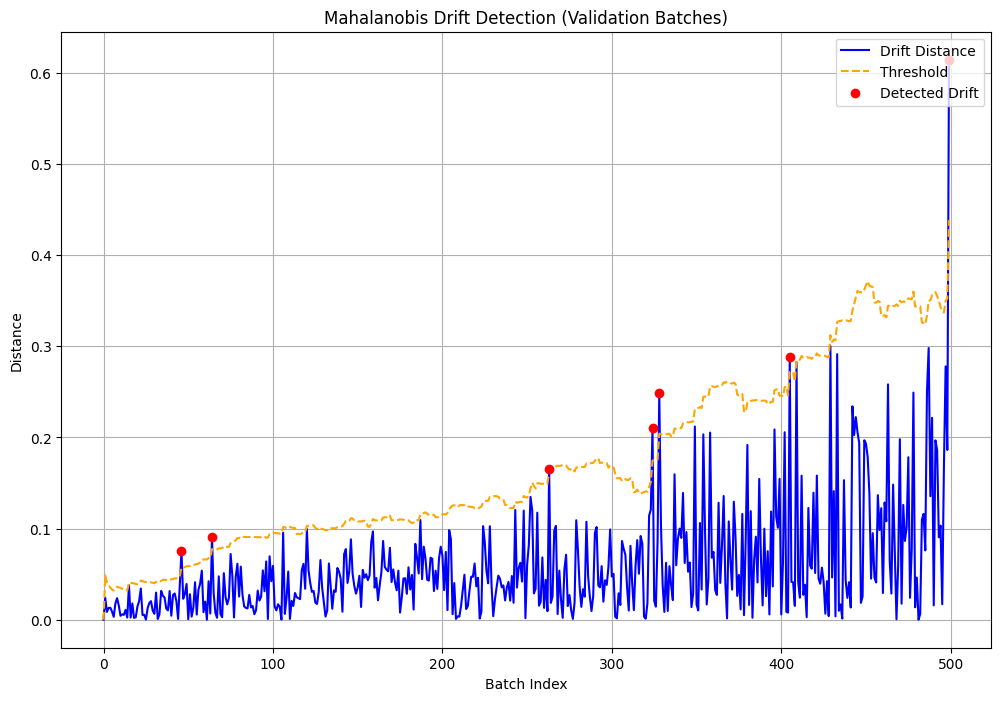


Evaluating Mahalanobis-based detection against ground truth...
Confusion Matrix:
  TP=0, FN=22, FP=7, TN=471
FPR=0.0146
Precision=0.0000, Recall=0.0000, F1=0.0000

Drift detection results saved.


In [24]:
#################################
# 5. Mahalanobis Drift Detection
#################################
print("\nPerforming Mahalanobis-based drift detection on validation set...")

window_size = 50
threshold_multiplier = 3.0
alpha = 0.01

tracker = DriftDetector(embedding_dim, alpha=alpha)
drift_distances = []
thresholds = []
predicted_drift_labels = []

# Split validation data into N time-based batches
n_batches = 500
batch_list = np.array_split(valid_data, n_batches)

with torch.no_grad():
    for batch_index, batch_df in enumerate(batch_list):
        # Prepare batch input for model
        batch_input = {key: batch_df[key].values for key in sparse_features}

        # Model predictions as embeddings (simple approach)
        embeddings = model.predict(batch_input)
        mean_embedding = np.mean(embeddings, axis=0)

        # Update and detect drift
        tracker.update(mean_embedding)
        drift_distance = tracker.detect_drift(mean_embedding)
        drift_distances.append(drift_distance)

        # Dynamic threshold
        if len(drift_distances) > window_size:
            recent = drift_distances[-window_size:]
            mean_dist = np.mean(recent)
            std_dist = np.std(recent)
            threshold = mean_dist + threshold_multiplier * std_dist
        else:
            threshold = (
                np.mean(drift_distances) +
                threshold_multiplier * np.std(drift_distances)
            )
        thresholds.append(threshold)

        # Predicted drift
        pred_label = 1 if drift_distance > threshold else 0
        predicted_drift_labels.append(pred_label)

        if pred_label == 1:
            print(
                f"Batch {batch_index}: Drift detected! "
                f"Distance={drift_distance:.4f}, Threshold={threshold:.4f}"
            )

# Plot drift distance vs. threshold, marking detected drifts
plt.figure(figsize=(12, 8))
plt.plot(drift_distances, label="Drift Distance", color="blue", linestyle="-")
plt.plot(thresholds, label="Threshold", color="orange", linestyle="--")
plt.scatter(
    range(len(predicted_drift_labels)), 
    [drift_distances[i] if predicted_drift_labels[i] == 1 else None for i in range(len(predicted_drift_labels))],
    color="red", 
    label="Detected Drift", 
    marker="o", 
    zorder=5
)
plt.title("Mahalanobis Drift Detection (Validation Batches)")
plt.xlabel("Batch Index")
plt.ylabel("Distance")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()


# %%
#################################
# 6. Evaluate Detection
#################################
print("\nEvaluating Mahalanobis-based detection against ground truth...")

# Ground truth: if > 6% of the batch has drift_flag=True, label batch as drift
actual_drift_labels = []
for batch_df in batch_list:
    drift_fraction = batch_df["drift_flag"].mean()
    batch_label = 1 if drift_fraction > 0.06 else 0
    actual_drift_labels.append(batch_label)

y_true = np.array(actual_drift_labels)
y_pred = np.array(predicted_drift_labels)

# Check lengths
assert len(y_true) == len(y_pred), "Mismatch in label lengths!"

tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

print("Confusion Matrix:")
print(f"  TP={tp}, FN={fn}, FP={fp}, TN={tn}")
print(f"FPR={fpr:.4f}")
print(f"Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}")

# Save distances/thresholds if desired
np.save("drift_distances_dl.npy", drift_distances)
np.save("drift_thresholds_dl.npy", thresholds)
print("\nDrift detection results saved.")




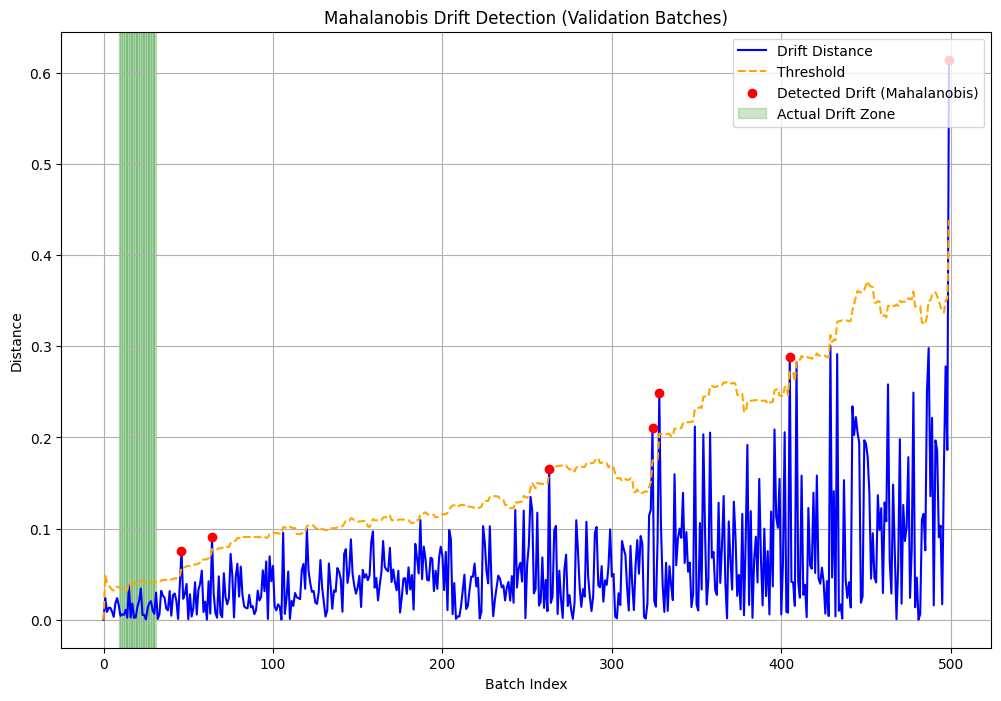

In [26]:
# Plot drift distance vs. threshold, marking detected drifts
plt.figure(figsize=(12, 8))
plt.plot(drift_distances, label="Drift Distance", color="blue", linestyle="-")
plt.plot(thresholds, label="Threshold", color="orange", linestyle="--")

# Show which batches we flagged as drift (predicted)
plt.scatter(
    range(len(predicted_drift_labels)), 
    [drift_distances[i] if predicted_drift_labels[i] == 1 else None for i in range(len(predicted_drift_labels))],
    color="red", 
    label="Detected Drift (Mahalanobis)", 
    marker="o", 
    zorder=5
)

# === NEW: Shade actual drift zones from ground-truth ===
already_labeled = False
for i in range(len(actual_drift_labels)):
    if actual_drift_labels[i] == 1:
        # Use axvspan to highlight the entire batch region
        # We'll label the first one so it shows up in the legend only once
        if not already_labeled:
            plt.axvspan(i, i+1, color='green', alpha=0.2, label="Actual Drift Zone")
            already_labeled = True
        else:
            plt.axvspan(i, i+1, color='green', alpha=0.2)

plt.title("Mahalanobis Drift Detection (Validation Batches)")
plt.xlabel("Batch Index")
plt.ylabel("Distance")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()
